In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries loaded")

✅ Libraries loaded


In [24]:
df = pd.read_csv('../Dataset/student_performance.csv')
print("Shape:", df.shape)
df.head()

Shape: (2392, 15)


,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0


In [25]:
print("=== Dataset Info ===")
df.info()
print("\n=== Missing Values ===")
print(df.isnull().sum())
print("\n=== Duplicates ===")
print("Duplicate rows:", df.duplicated().sum())

=== Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StudentID          2392 non-null   int64  
 1   Age                2392 non-null   int64  
 2   Gender             2392 non-null   int64  
 3   Ethnicity          2392 non-null   int64  
 4   ParentalEducation  2392 non-null   int64  
 5   StudyTimeWeekly    2392 non-null   float64
 6   Absences           2392 non-null   int64  
 7   Tutoring           2392 non-null   int64  
 8   ParentalSupport    2392 non-null   int64  
 9   Extracurricular    2392 non-null   int64  
 10  Sports             2392 non-null   int64  
 11  Music              2392 non-null   int64  
 12  Volunteering       2392 non-null   int64  
 13  GPA                2392 non-null   float64
 14  GradeClass         2392 non-null   float64
dtypes: float64(3), int64(12)
memory usage: 280.4 KB

=== Missing V

In [26]:
df.drop(columns=['StudentID'], inplace=True)
print("✅ Dropped StudentID")
print("Shape:", df.shape)

✅ Dropped StudentID
Shape: (2392, 14)


In [27]:
df.drop_duplicates(inplace=True)
print("After removing duplicates:", df.shape)

After removing duplicates: (2392, 14)


In [28]:
print("Target column (GradeClass) distribution:")
print(df['GradeClass'].value_counts())
grade_map = {0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'F'}
print("\nMeaning:", grade_map)

Target column (GradeClass) distribution:
GradeClass
4.0    1211
3.0     414
2.0     391
1.0     269
0.0     107
Name: count, dtype: int64

Meaning: {0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'F'}


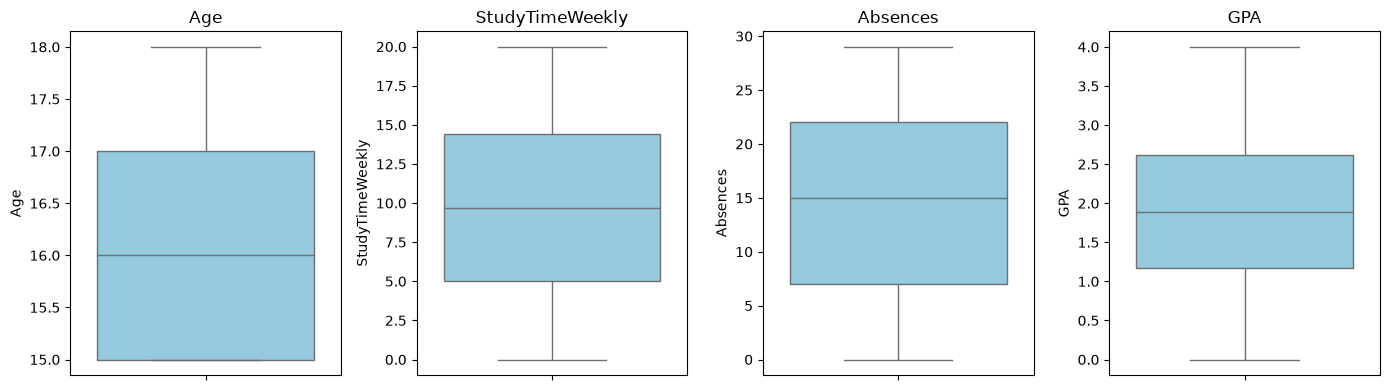

✅ Boxplot saved


In [29]:
num_cols = ['Age', 'StudyTimeWeekly', 'Absences', 'GPA']

plt.figure(figsize=(14, 4))
for i, col in enumerate(num_cols):
    plt.subplot(1, 4, i+1)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(col)
plt.tight_layout()
plt.savefig('../Documentation/outlier_boxplots.png')
plt.show()
print("✅ Boxplot saved")

In [30]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower, upper)

print("✅ Outliers treated")

✅ Outliers treated


In [31]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])
print("✅ Normalization done")
df.head()

✅ Normalization done


,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,0.666667,1,0,2,0.992773,0.241379,1,2,0,0,1,0,0.732299,2.0
1,1.000000,0,0,1,0.771270,0.000000,0,1,0,0,0,0,0.760729,1.0
2,0.000000,0,2,3,0.210718,0.896552,0,2,0,0,0,0,0.028151,4.0
3,0.666667,1,0,3,0.501965,0.482759,0,3,1,0,0,0,0.513555,3.0
4,0.666667,1,0,2,0.233840,0.586207,1,3,0,0,0,0,0.322015,4.0


In [32]:
df.to_csv('../Dataset/cleaned_data.csv', index=False)
print("✅ Cleaned data saved")
print("Final shape:", df.shape)

✅ Cleaned data saved
Final shape: (2392, 14)
